In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [38]:
import numpy as np
from loguru import logger
import pylab as plt

from stable_baselines3 import PPO

In [5]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Roi import RoiBuilderParams

from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import run_method
from vimms_gym.common import METHOD_TOPN, METHOD_PPO
from vimms_gym.visualisation import plot_N, plot_ms1_ms2_counts, plot_action_hist, plot_action_probs, plot_reward_probs

# 1. Parameters

In [6]:
n_chemicals = (5000, 20000)
mz_range = (70, 1000)
rt_range = (0, 1440)
intensity_range = (1E4, 1E20)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mzml_filename = '../fullscan_QCB.mzML'
samplers = None
samplers_pickle = 'samplers_fullscan_QCB.mzML.p'
if exists(samplers_pickle):
    logger.info('Loaded %s' % samplers_pickle)
    samplers = load_obj(samplers_pickle)
    mz_sampler = samplers['mz']
    ri_sampler = samplers['rt_intensity']
    cr_sampler = samplers['chromatogram']
else:
    logger.info('Creating samplers from %s' % mzml_filename)
    mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
    ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                           min_log_intensity=min_log_intensity,
                                           max_log_intensity=max_log_intensity)
    roi_params = RoiBuilderParams(min_roi_length=3, at_least_one_point_above=1000)
    cr_sampler = MZMLChromatogramSampler(mzml_filename, roi_params=roi_params)
    samplers = {
        'mz': mz_sampler,
        'rt_intensity': ri_sampler,
        'chromatogram': cr_sampler
    }
    save_obj(samplers, samplers_pickle)

2022-05-03 11:19:31.752 | INFO     | __main__:<cell line: 4>:5 - Loaded samplers_fullscan_QCB.mzML.p


In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 200
in_dir = 'results'

In [12]:
n_eval_episodes = 1
deterministic = True

# 2. Evaluation

## Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0


## Run different methods

In [15]:
eval_dir = 'visualisation'

In [16]:
for chems in chem_list:
    print(len(chems))

10703


In [17]:
max_peaks

200

In [18]:
out_dir = eval_dir
in_dir, out_dir

('results', 'visualisation')

In [19]:
all_results = {}

In [20]:
env_name = 'DDAEnv'

### Run PPO

In [21]:
method = METHOD_PPO

In [22]:
model_name = 'PPO'

In [23]:
effective_rt_tol = rt_tol
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [24]:
fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
model = PPO.load(fname)

In [25]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, model=model, print_eval=True, print_reward=True)


Episode 0 (10703 chemicals)
steps	 500 	total rewards	 140.97765423369174
steps	 1000 	total rewards	 307.9252341830855
steps	 1500 	total rewards	 497.36440612029816
steps	 2000 	total rewards	 675.1873277174211
steps	 2500 	total rewards	 844.230564797597
steps	 3000 	total rewards	 1002.4235846944425
steps	 3500 	total rewards	 1160.5662106890131
steps	 4000 	total rewards	 1322.2483756276242
steps	 4500 	total rewards	 1494.5697958495762
steps	 5000 	total rewards	 1659.643444406704
steps	 5500 	total rewards	 1820.949438939036
Finished after 5708 timesteps with total reward 1876.4672451302044
{'coverage_prop': '0.377', 'intensity_prop': '0.266', 'ms1/ms2 ratio': '0.353', 'efficiency': '0.958', 'TP': '2139', 'FP': '473', 'FN': '8091', 'precision': '0.819', 'recall': '0.209', 'f1': '0.333'}


In [26]:
ppo_result = results[0]
ppo_result

### Run Top-N

In [27]:
method = METHOD_TOPN

In [28]:
effective_rt_tol = exclusion_t_0
copy_params = dict(params)        
copy_params['env']['rt_tol'] = effective_rt_tol

In [29]:
model = None

In [30]:
results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, N=10, model=model, print_eval=True, print_reward=True)


Episode 0 (10703 chemicals)
steps	 500 	total rewards	 128.23657994149252
steps	 1000 	total rewards	 280.49860483711655
steps	 1500 	total rewards	 422.51212260106433
steps	 2000 	total rewards	 571.2959474034584
steps	 2500 	total rewards	 725.0471705858934
steps	 3000 	total rewards	 867.0308011717489
steps	 3500 	total rewards	 983.62100320379
steps	 4000 	total rewards	 1074.1084485210765
steps	 4500 	total rewards	 1186.9545724082113
steps	 5000 	total rewards	 1312.606088463554
steps	 5500 	total rewards	 1430.2982275765482
steps	 6000 	total rewards	 1543.9525115825827
Finished after 6199 timesteps with total reward 1583.1729834282569
{'coverage_prop': '0.350', 'intensity_prop': '0.248', 'ms1/ms2 ratio': '0.192', 'efficiency': '0.721', 'TP': '1962', 'FP': '381', 'FN': '8360', 'precision': '0.837', 'recall': '0.190', 'f1': '0.310'}


In [31]:
topN_result = results[0]
topN_result

# 3. Visualisation

## Visualise some results from the first episode

Limit some plots to the first 1000 steps.

In [32]:
limit = 1000

Plot the distribution of N: the number of MS2 scans that follow an MS1 scan

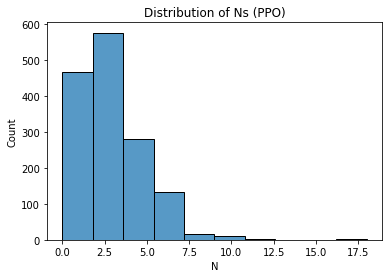

In [33]:
plot_N(ppo_result, bins=10, title='Distribution of Ns (PPO)')

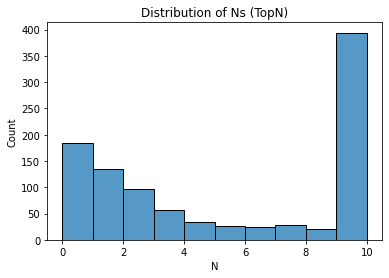

In [34]:
plot_N(topN_result, bins=10, title='Distribution of Ns (TopN)')

Plot the number of MS1 and MS2 scans over time

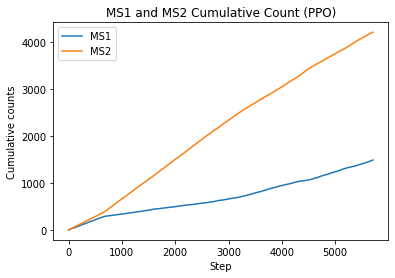

In [35]:
ppo_ms1, ppo_ms2 = plot_ms1_ms2_counts(ppo_result, title='MS1 and MS2 Cumulative Count (PPO)')

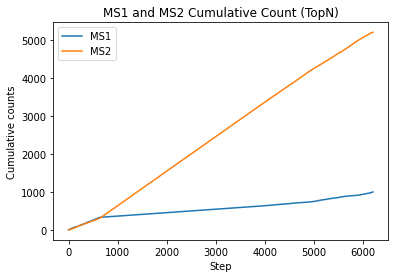

In [36]:
topN_ms1, topN_ms2 = plot_ms1_ms2_counts(topN_result, title='MS1 and MS2 Cumulative Count (TopN)')

Text(0.5, 1.0, 'MS2 Cumulative Counts')

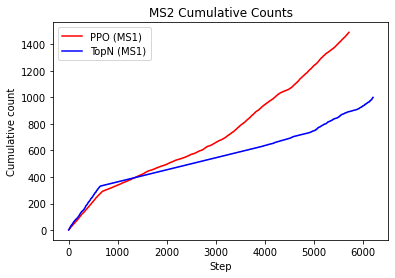

In [39]:
plt.plot(ppo_ms1, 'r-', label='PPO (MS1)')
plt.plot(topN_ms1, 'b-', label='TopN (MS1)')
plt.legend()
plt.ylabel('Cumulative count')
plt.xlabel('Step')
plt.title('MS2 Cumulative Counts')

Plot a histogram of all actions.

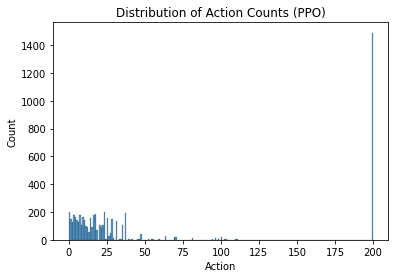

In [40]:
plot_action_hist(ppo_result, bins=200, title='Distribution of Action Counts (PPO)')

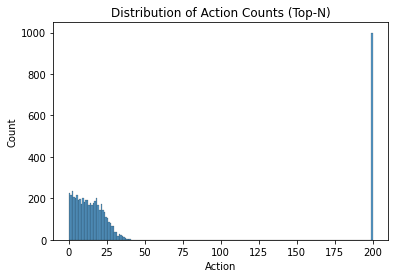

In [41]:
plot_action_hist(topN_result, bins=200, title='Distribution of Action Counts (Top-N)')

Plot a histogram of MS2-actions only

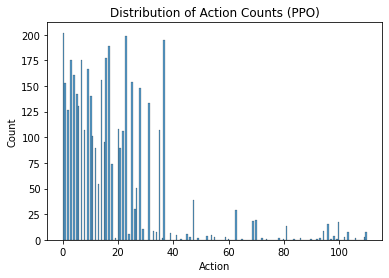

In [42]:
plot_action_hist(ppo_result, ms2_only=True, bins=199, title='Distribution of Action Counts (PPO)')

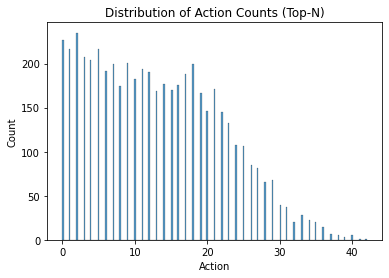

In [43]:
plot_action_hist(topN_result, ms2_only=True, bins=199, title='Distribution of Action Counts (Top-N)')

Show the first few actions

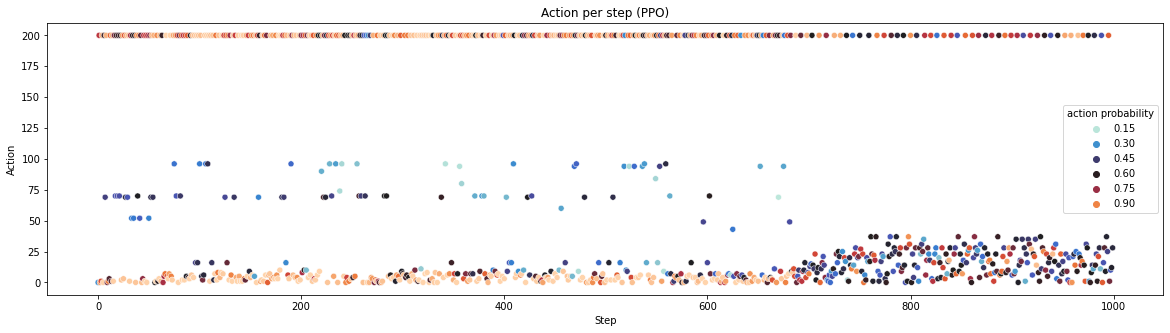

In [44]:
plot_action_probs(ppo_result, limit, max_peaks, title='Action per step (PPO)')

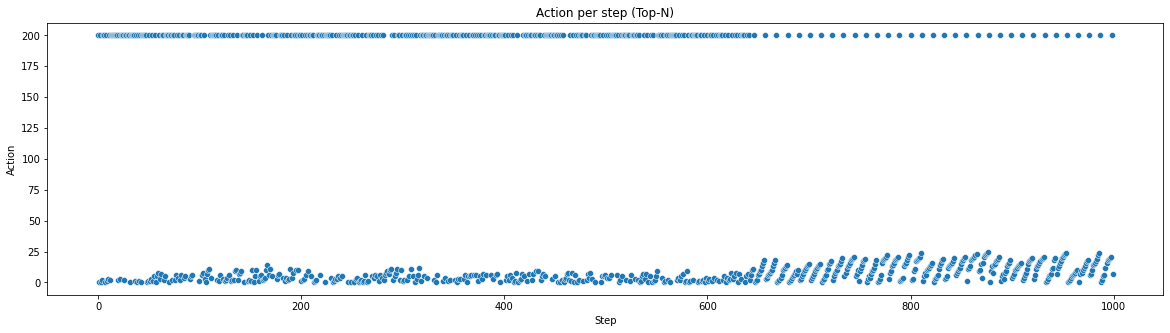

In [45]:
plot_action_probs(topN_result, limit, max_peaks, title='Action per step (Top-N)')

Plot rewards coloured by action probabilities

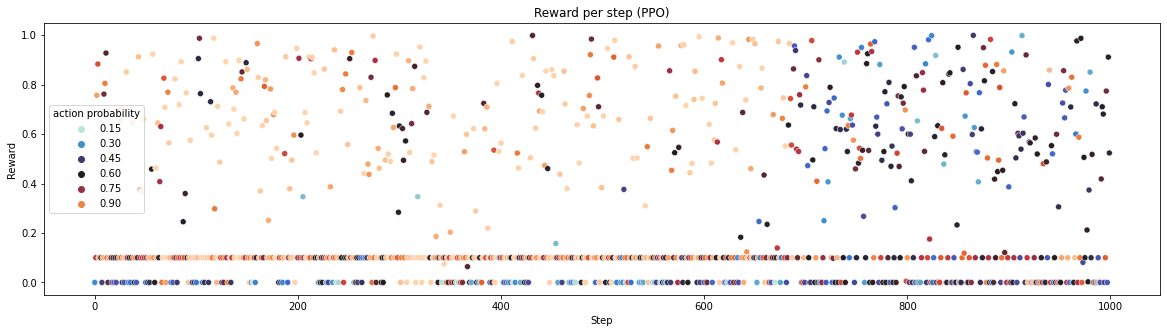

In [46]:
plot_reward_probs(ppo_result, limit, max_peaks, title='Reward per step (PPO)')

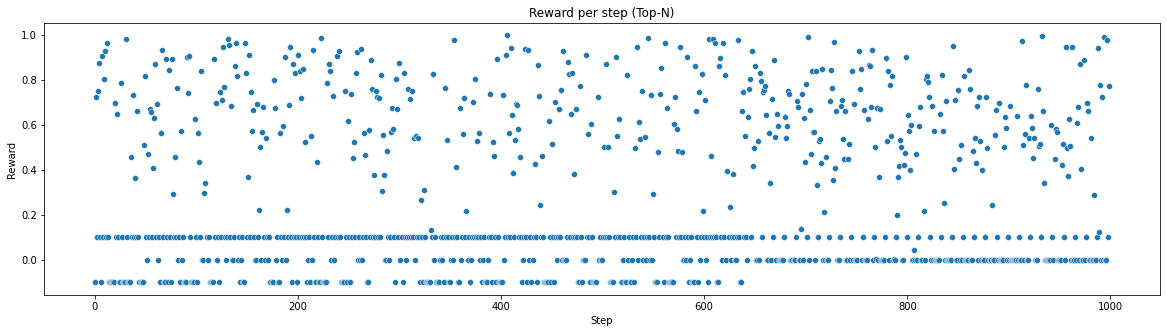

In [47]:
plot_reward_probs(topN_result, limit, max_peaks, title='Reward per step (Top-N)')